In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
    df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# No NA Values

In [7]:
df[df.Churn=='Yes'].shape[0]/df[df.Churn=='No'].shape[0] 

0.36122922303826827

In [8]:
np.dtype(df.TotalCharges)

ValueError: Could not convert 0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str to a NumPy dtype (via `.dtype` value <StringDtype(na_value=nan)>).

In [9]:
#By looking at the above error, we can understand the reason behind the dtype('o')

len(df[df.TotalCharges==' ']) #We have 11 records with Total Charges value -> ' ' and all these rows have Churn value 'NO', let's remove these rows from our analysis (Having information on Churned customers is more important than info on unchurned records)  
df=df[df.TotalCharges!=' ']

df.TotalCharges=pd.to_numeric(df.TotalCharges)
np.dtype(df.TotalCharges)


dtype('float64')

In [10]:
#Ideally SeniorCitizen column should be a factor, so let's convert 1,0 values to Yes,No and later we can label encode all factor columns

df.SeniorCitizen=df.SeniorCitizen.apply(lambda x: 'Yes' if x==1 else 'No')
df.SeniorCitizen.value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

In [11]:
cat_cols_for_wrangling=['MultipleLines','DeviceProtection','OnlineBackup','OnlineSecurity','StreamingMovies','StreamingTV','TechSupport','InternetService']

In [12]:
#Some Data Wrangling.. We will Convert values like 'No Phone Service', 'No Internet Service' to 'No'. In other words, we're creating binary columns (Yes or No)

for col in cat_cols_for_wrangling:
    df[col]=df[col].apply(lambda x: 'No' if 'No' in x else 'Yes')

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [14]:
cols=df.columns
cols=cols.drop(['customerID','MonthlyCharges','TotalCharges'])
all_cat_cols=list(cols) #All the categorical features that are required for analysis, we'll remove customerID since it's just an ID column with no significance for the analysis

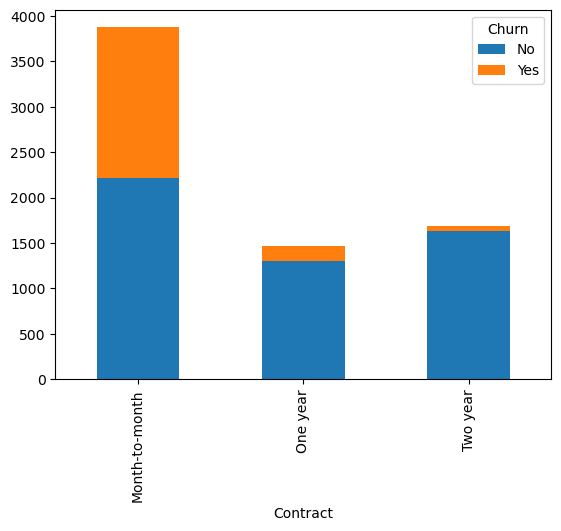

In [15]:
df.groupby(['Contract','Churn']).size().unstack().plot(kind='bar',stacked=True); #Clearly, users with Month-to-Month contract are more likely to churn 

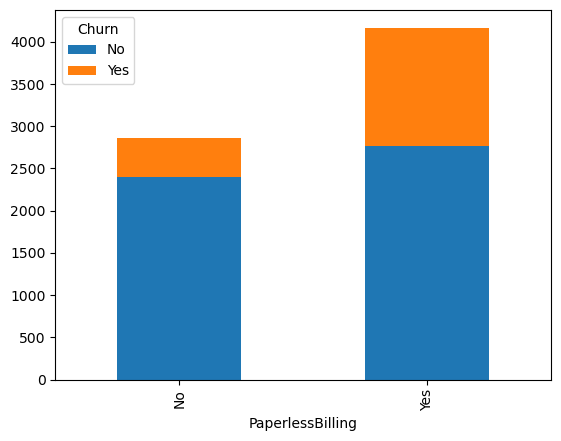

In [16]:
df.groupby(['PaperlessBilling','Churn']).size().unstack().plot(kind='bar',stacked=True);

<Axes: >

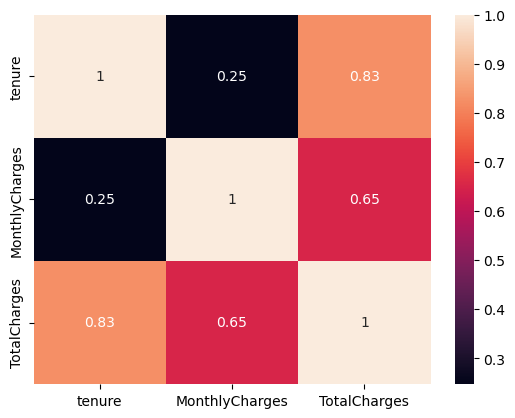

In [17]:
sns.heatmap(
    df.drop('customerID', axis=1)
      .select_dtypes(include='number')
      .corr(),
    annot=True
)

In [18]:
#It makes more sense to categorize customers wrt tenure, so let's convert tenure column to tenure range/buckets

def convert_to_buckets(tenure):
    
    if tenure <=24:
        return '0 - 24 months'
    elif tenure <=36:
        return '24 - 36 months'
    elif tenure <=48:
        return '36 - 48 months'
    elif tenure <=60:
        return '48 - 60 months'
    else:
        return '> 60 months'

In [19]:
df['tenure']=df['tenure'].map(convert_to_buckets)
df['tenure'].value_counts()

tenure
0 - 24 months     3199
> 60 months       1407
24 - 36 months     832
48 - 60 months     832
36 - 48 months     762
Name: count, dtype: int64

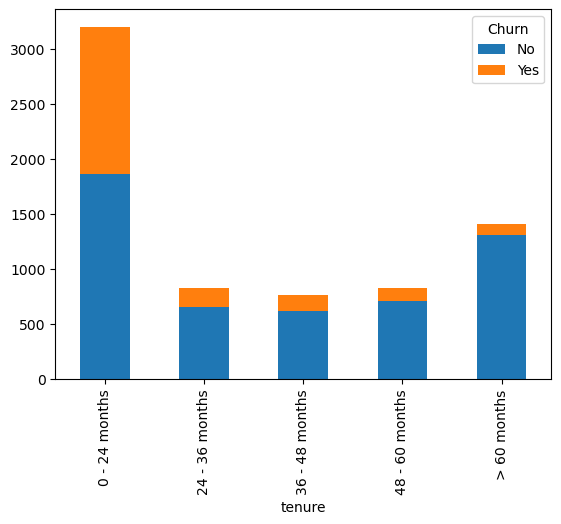

In [20]:
df.groupby(['tenure','Churn']).size().unstack().plot(kind='bar',stacked=True); #customers with 0-24 months tenure are more likely to churn.. 
#From the plot, it is evident that 'tenure' is an important feature as well./

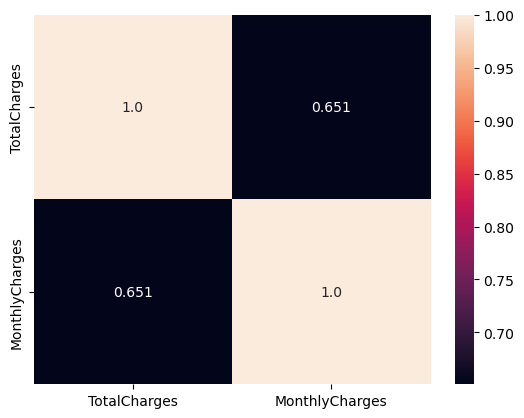

In [21]:
sns.heatmap(df[['TotalCharges','MonthlyCharges']].corr(),annot=True,fmt='.3');
#Since, monthly and Total Charges are corelated.. We'd need to remove one of them, let's remove TotalCharges..

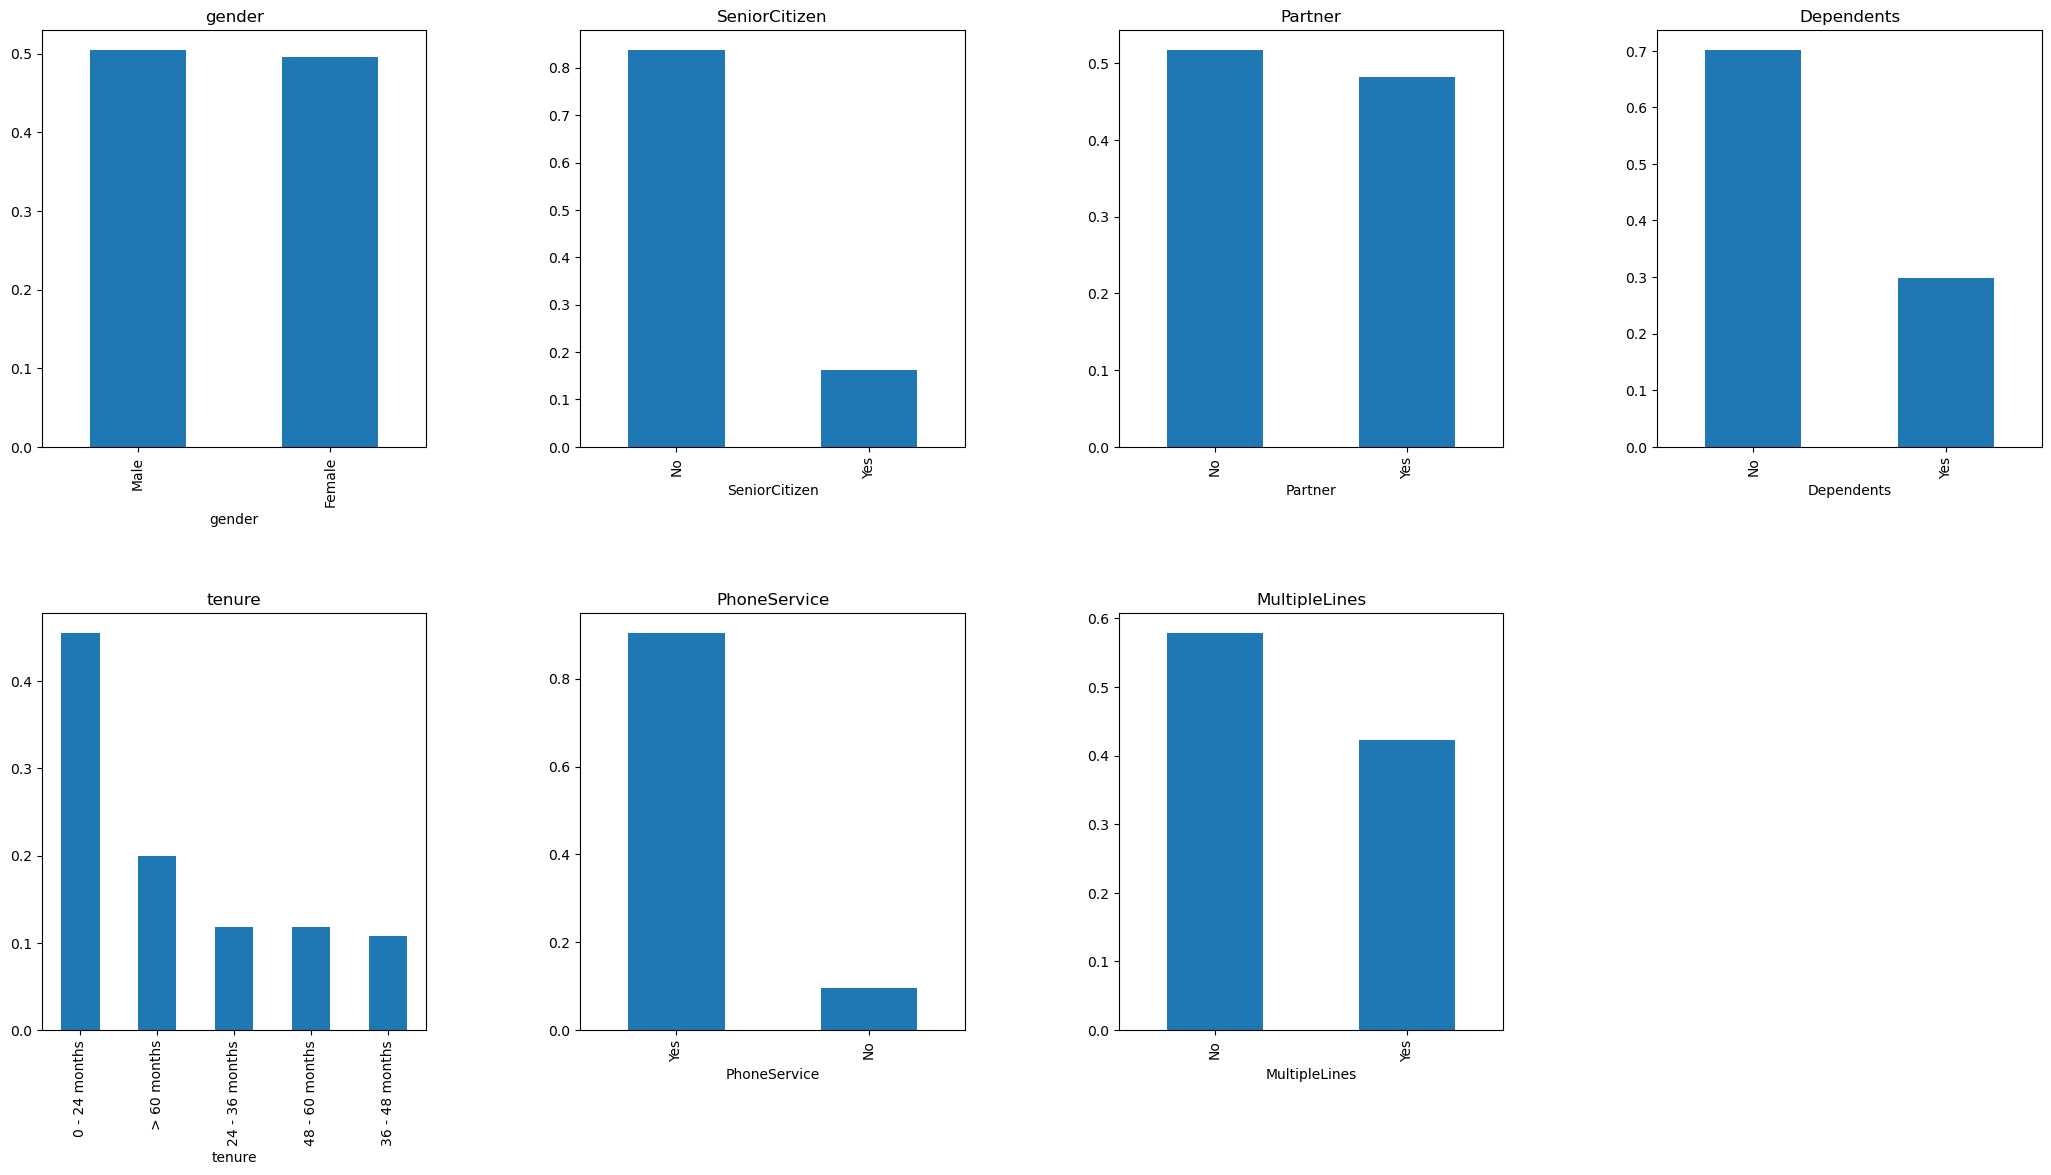

In [22]:

f=plt.figure(figsize=(10,10));
for i in range(7):
    f.add_subplot(2,4,i+1)
    df[all_cat_cols[i]].value_counts(normalize=True).plot(kind='bar',title=all_cat_cols[i])
plt.subplots_adjust(left=3,right=5,top=3,bottom=2,wspace = 0.4,hspace = 0.4)

In [23]:
all_cat_cols #All Categorical column names

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [24]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

for col in all_cat_cols:
    df[col] = labelencoder.fit_transform(df[col])
    

df[all_cat_cols].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,2,0
1,1,0,0,0,1,1,0,1,1,0,1,0,0,0,1,0,3,0
2,1,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,3,1
3,1,0,0,0,2,0,0,1,1,0,1,1,0,0,1,0,0,0
4,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1


In [25]:

# TRAIN-TEST SPLIT

In [26]:
from sklearn.model_selection import train_test_split

X_train=df.sample(frac=0.8,random_state=199)
X_test=df.drop(X_train.index)
len(X_train),len(X_test)

(5626, 1406)

In [27]:
Y_train=X_train['Churn']
Y_test=X_test['Churn']

In [28]:
#Monthly and TotalCharges are corelated, so we remove one of them, we're removing total charges

X_train.drop(columns=['Churn','customerID','TotalCharges'] , inplace=True)
X_test.drop(columns=['Churn','customerID','TotalCharges'], inplace=True)

X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges'],
      dtype='str')

In [29]:
# LOGISTIC REGRESSION

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

log_model=LogisticRegression(class_weight='balanced')#https://stackoverflow.com/questions/30972029/how-does-the-class-weight-parameter-in-scikit-learn-work
log_model.fit(X_train,Y_train)

Y_pred=log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
accuracy_score(Y_test, Y_pred)

0.7290184921763869

In [32]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(Y_test, log_probs)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.825732754241593


In [33]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1020
           1       0.50      0.79      0.61       386

    accuracy                           0.73      1406
   macro avg       0.70      0.75      0.70      1406
weighted avg       0.79      0.73      0.74      1406



In [34]:
# LOGISTIC REGRESSION - THRESHOLD ANALYSIS

log_probs = log_model.predict_proba(X_test)

Y_log_pred = {}

for i in range(1, 7):
    
    threshold = 0.15 * i
    
    Y_log_pred[str(threshold)] = (
        log_probs[:, 1] > threshold
    ).astype('int')
    
    print(
        'Threshold at', threshold, ':\n',
        classification_report(
            Y_test,
            Y_log_pred[str(threshold)]
        ),
        '\n'
    )

len(Y_log_pred)

Threshold at 0.15 :
               precision    recall  f1-score   support

           0       0.96      0.37      0.54      1020
           1       0.37      0.96      0.53       386

    accuracy                           0.54      1406
   macro avg       0.67      0.67      0.54      1406
weighted avg       0.80      0.54      0.54      1406
 

Threshold at 0.3 :
               precision    recall  f1-score   support

           0       0.94      0.53      0.68      1020
           1       0.42      0.91      0.58       386

    accuracy                           0.64      1406
   macro avg       0.68      0.72      0.63      1406
weighted avg       0.80      0.64      0.65      1406
 

Threshold at 0.44999999999999996 :
               precision    recall  f1-score   support

           0       0.91      0.68      0.77      1020
           1       0.49      0.81      0.61       386

    accuracy                           0.71      1406
   macro avg       0.70      0.74      0.69    

6

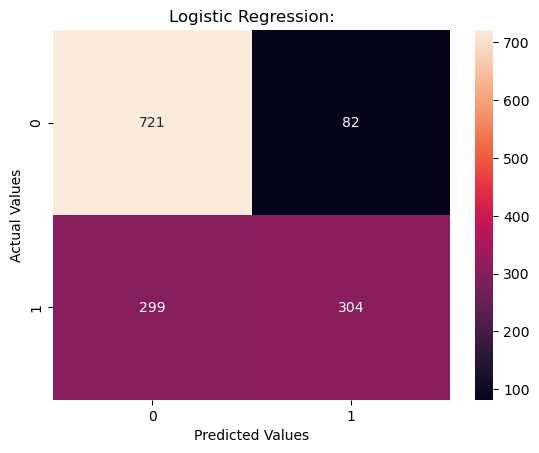

In [35]:
sns.heatmap(confusion_matrix(Y_pred,Y_test),annot=True,fmt='1')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Logistic Regression:'); #';' to exclude printing 'plt' object details 

In [36]:
# RANDOM FOREST CLASSIFIER

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier()

In [38]:
rf_model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
Y_rf_Pred=rf_model.predict(X_test)
model_probs = rf_model.predict_proba(X_test)[:, 1]

In [40]:
print(classification_report(Y_test, Y_rf_Pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1020
           1       0.63      0.45      0.53       386

    accuracy                           0.78      1406
   macro avg       0.72      0.68      0.69      1406
weighted avg       0.76      0.78      0.76      1406



In [41]:
auc_score = roc_auc_score(Y_test, model_probs)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.7920184395001523


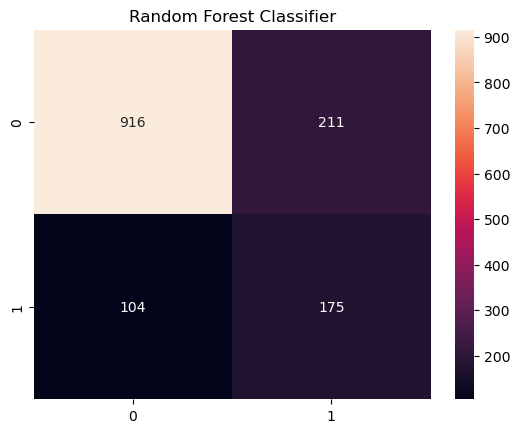

In [42]:
sns.heatmap(confusion_matrix(Y_rf_Pred,Y_test),annot=True,fmt='1')
plt.title('Random Forest Classifier');

In [43]:
# RANDOM FOREST - THRESHOLD ANALYSIS

probs = rf_model.predict_proba(X_test)

Y_rf_pred_threshold = {}

for i in range(1, 7):
    
    threshold = 0.15 * i
    
    Y_rf_pred_threshold[str(threshold)] = (
        probs[:, 1] > threshold
    ).astype('int')
    
    print(
        'Threshold at', threshold, ':\n',
        classification_report(
            Y_test,
            Y_rf_pred_threshold[str(threshold)]
        ),
        '\n'
    )

Threshold at 0.15 :
               precision    recall  f1-score   support

           0       0.91      0.58      0.71      1020
           1       0.44      0.85      0.58       386

    accuracy                           0.66      1406
   macro avg       0.67      0.72      0.64      1406
weighted avg       0.78      0.66      0.67      1406
 

Threshold at 0.3 :
               precision    recall  f1-score   support

           0       0.86      0.76      0.81      1020
           1       0.52      0.67      0.59       386

    accuracy                           0.74      1406
   macro avg       0.69      0.72      0.70      1406
weighted avg       0.77      0.74      0.75      1406
 

Threshold at 0.44999999999999996 :
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      1020
           1       0.62      0.52      0.57       386

    accuracy                           0.78      1406
   macro avg       0.72      0.70      0.71    

In [44]:
# Gradient Boosting

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf=GradientBoostingClassifier()
gb_clf.fit(X_train,Y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [46]:
Y_Pred=gb_clf.predict(X_test)
clf_probs = gb_clf.predict_proba(X_test)[:, 1]

In [47]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1020
           1       0.50      0.79      0.61       386

    accuracy                           0.73      1406
   macro avg       0.70      0.75      0.70      1406
weighted avg       0.79      0.73      0.74      1406



In [48]:
# GRADIENT BOOSTING - THRESHOLD ANALYSIS

gb_probs = gb_clf.predict_proba(X_test)

Y_gb_pred_threshold = {}

for i in range(1, 7):
    
    threshold = 0.15 * i
    
    Y_gb_pred_threshold[str(threshold)] = (
        gb_probs[:, 1] > threshold
    ).astype('int')
    
    print(
        'Threshold at', threshold, ':\n',
        classification_report(
            Y_test,
            Y_gb_pred_threshold[str(threshold)]
        ),
        '\n'
    )

len(Y_gb_pred_threshold)

Threshold at 0.15 :
               precision    recall  f1-score   support

           0       0.93      0.57      0.71      1020
           1       0.44      0.89      0.59       386

    accuracy                           0.66      1406
   macro avg       0.69      0.73      0.65      1406
weighted avg       0.80      0.66      0.68      1406
 

Threshold at 0.3 :
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1020
           1       0.53      0.74      0.62       386

    accuracy                           0.75      1406
   macro avg       0.71      0.75      0.72      1406
weighted avg       0.79      0.75      0.76      1406
 

Threshold at 0.44999999999999996 :
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1020
           1       0.64      0.56      0.60       386

    accuracy                           0.79      1406
   macro avg       0.74      0.72      0.73    

C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


6

<Axes: >

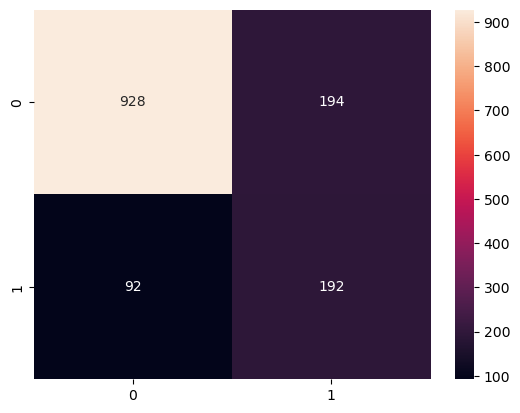

In [49]:
sns.heatmap(confusion_matrix(Y_Pred,Y_test),annot=True,fmt='1')

In [50]:
auc_score = roc_auc_score(Y_test, clf_probs)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8321814995428223


In [51]:
# Histogram Gradient_Boosting

In [52]:
from sklearn.ensemble import HistGradientBoostingClassifier
gb_model = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=100,
    random_state=42
)

gb_model.fit(X_train, Y_train)

,loss,'log_loss'
,learning_rate,0.03
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [53]:
Y_gb_pred = gb_model.predict(X_test)

Y_gb_probs=gb_model.predict_proba(X_test)[:, 1]

In [54]:
# HISTGRADIENT BOOSTING - THRESHOLD ANALYSIS

hgb_probs = gb_model.predict_proba(X_test)

Y_hgb_pred_threshold = {}

for i in range(1, 7):
    
    threshold = 0.15 * i
    
    Y_hgb_pred_threshold[str(threshold)] = (
        hgb_probs[:, 1] > threshold
    ).astype('int')
    
    print(
        'Threshold at', threshold, ':\n',
        classification_report(
            Y_test,
            Y_hgb_pred_threshold[str(threshold)]
        ),
        '\n'
    )

len(Y_hgb_pred_threshold)

Threshold at 0.15 :
               precision    recall  f1-score   support

           0       0.94      0.54      0.69      1020
           1       0.43      0.91      0.59       386

    accuracy                           0.65      1406
   macro avg       0.69      0.73      0.64      1406
weighted avg       0.80      0.65      0.66      1406
 

Threshold at 0.3 :
               precision    recall  f1-score   support

           0       0.88      0.75      0.81      1020
           1       0.53      0.73      0.61       386

    accuracy                           0.75      1406
   macro avg       0.70      0.74      0.71      1406
weighted avg       0.78      0.75      0.76      1406
 

Threshold at 0.44999999999999996 :
               precision    recall  f1-score   support

           0       0.85      0.88      0.86      1020
           1       0.65      0.57      0.61       386

    accuracy                           0.80      1406
   macro avg       0.75      0.73      0.74    

C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ritik\Downloads\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


6

In [55]:
print("Accuracy Score:")
print(accuracy_score(Y_test, Y_gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_gb_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_gb_pred))

Accuracy Score:
0.7916073968705548

Confusion Matrix:
[[928  92]
 [201 185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1020
           1       0.67      0.48      0.56       386

    accuracy                           0.79      1406
   macro avg       0.74      0.69      0.71      1406
weighted avg       0.78      0.79      0.78      1406



In [56]:
auc_score = roc_auc_score(Y_test, Y_gb_probs)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.825888956618917


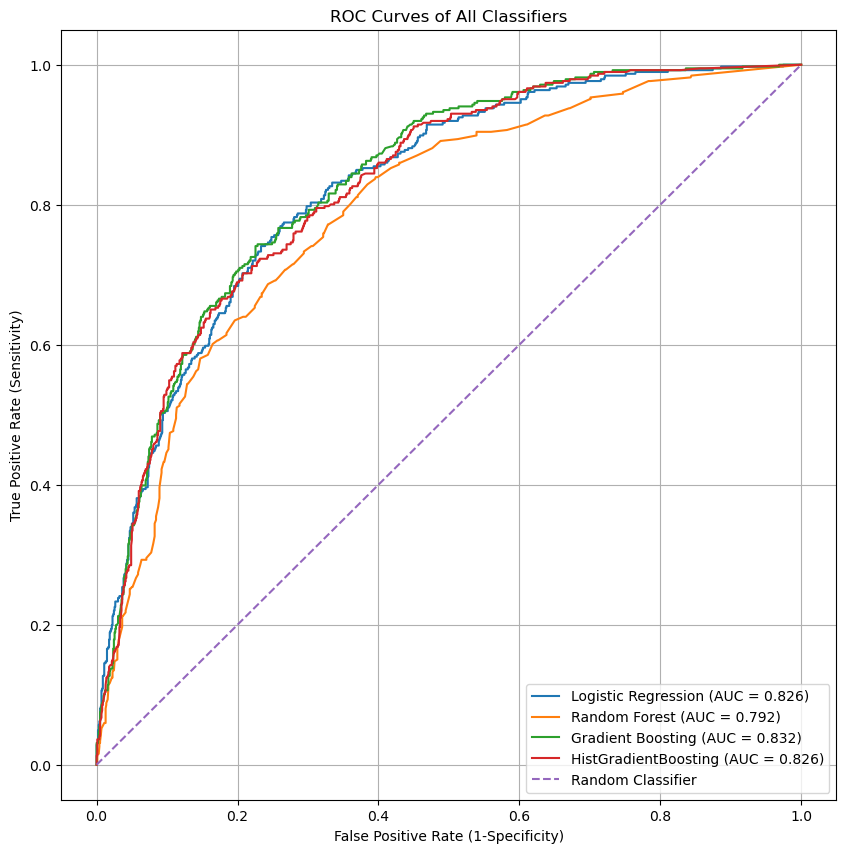

In [57]:
# ROC CURVES OF ALL CLASSIFIERS

plt.figure(figsize=(10, 10))

models = {
    'Logistic Regression': log_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_clf,
    'HistGradientBoosting': gb_model
}

for model_name, model in models.items():
    
    # Get probability of churn = 1
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # ROC curve
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    
    # ROC-AUC
    auc = roc_auc_score(Y_test, y_probs)
    
    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc:.3f})'
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves of All Classifiers')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
                              # END OF NOTEBOOK